In [3]:
%load_ext autoreload
%autoreload 2

from tqdm import tqdm
from trees.data import Data
from trees.causal_tree import CT
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

s = 0.3
K = 5
w = 0.6
ns = [1000, 10000, 100000, 1000000]


cols = ['condition', 'cate', 'distance', 'T0', 'T1', 'depth', 'norm_cate',
       'score','algorithm', 'n_observations']

scores = pd.DataFrame(columns=cols)

for n in ns:
    print(f"n: {n}")
    for exp in tqdm(range(10)):
        data = Data()
        data.generate(n=n, seed=exp)
        data.generate_random_condition(selectivity_threshold=s)

        ct_D = CT(data, on = "D")
        ct_D.parse_tree()
        ct_D_score = ct_D.get_topK(k=K, w=w, print_summaries=False)
        ct_D_score['n_observations'] = n
        scores=pd.concat([scores, ct_D_score], ignore_index=True)

        ct_P = CT(data, on = "P")
        ct_P.parse_tree()
        ct_P_score = ct_P.get_topK(k=K, w=w, print_summaries=False)
        ct_P_score['n_observations'] = n
        scores=pd.concat([scores, ct_P_score], ignore_index=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
n: 1000


100%|██████████| 10/10 [00:00<00:00, 40.31it/s]


n: 10000


100%|██████████| 10/10 [00:02<00:00,  4.92it/s]


n: 100000


100%|██████████| 10/10 [00:31<00:00,  3.14s/it]


n: 1000000


100%|██████████| 10/10 [09:27<00:00, 56.78s/it]


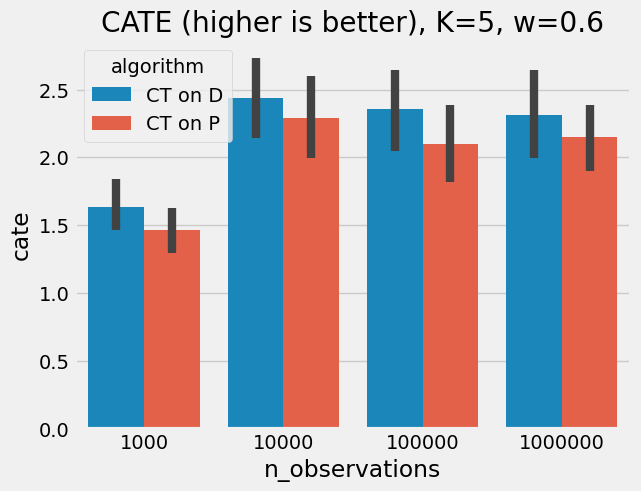

In [4]:
sns.barplot(x='n_observations', y='cate', hue='algorithm', data=scores)
plt.title(f"CATE (higher is better), K={str(K)}, w={str(w)}")
plt.show()

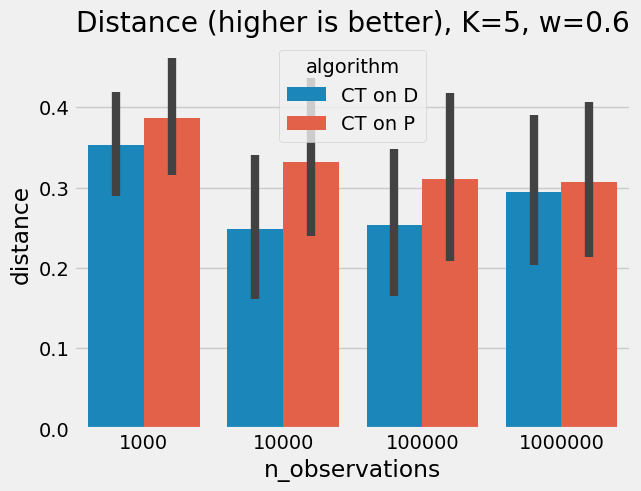

In [5]:
sns.barplot(x='n_observations', y='distance',hue="algorithm", data=scores)
plt.title(f"Distance (higher is better), K={str(K)}, w={str(w)}")
plt.show()

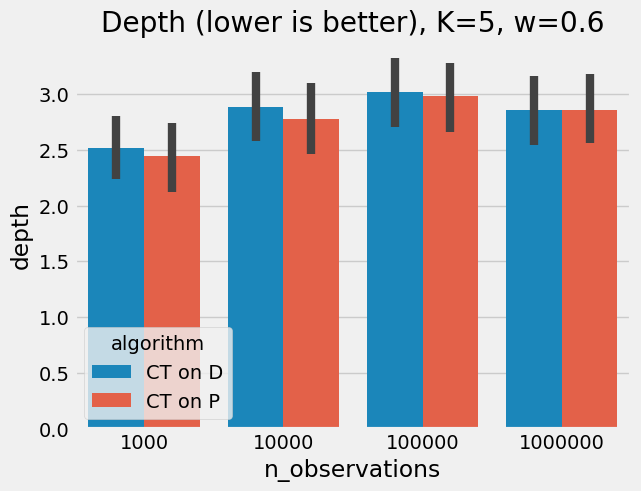

In [6]:
sns.barplot(x='n_observations', y='depth', hue="algorithm", data=scores)
plt.title(f"Depth (lower is better), K={str(K)}, w={str(w)}")
plt.show()